In [9]:
import requests
from bs4 import BeautifulSoup

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36"
}
response = requests.get("https://www.imdb.com/chart/top/", headers=headers)
html = response.text
soup = BeautifulSoup(html, "html.parser")
all_titles = soup.find_all("h3", attrs={"class": "ipc-title__text"})
movies = []
for title in all_titles:
    title_string = title.get_text()
    if title_string[0].isdigit():
        movies.append(title_string.split(". ", 1)[1])

print(response.status_code, len(movies))
print(movies[:5])

202 0
[]


In [10]:
print(response.headers.get("x-amzn-waf-action"))
print(len(response.text))
print(response.text[:300])

challenge
0



In [11]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

options = webdriver.ChromeOptions()
options.add_argument("--lang=en-US")
driver = webdriver.Chrome(options=options)

try:
    driver.get("https://www.imdb.com/chart/top/")
    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "h3.ipc-title__text"))
    )
    html = driver.page_source
finally:
    driver.quit()

soup = BeautifulSoup(html, "html.parser")
movies = []
for title in soup.find_all("h3", attrs={"class": "ipc-title__text"}):
    title_string = title.get_text()
    if title_string[0].isdigit():
        movies.append(title_string.split(". ", 1)[1])

print(len(movies))
print(movies[:5])

TimeoutException: Message: 
Stacktrace:
0   chromedriver                        0x0000000103014a84 chromedriver + 3508868
1   chromedriver                        0x0000000102d00f10 chromedriver + 282384
2   chromedriver                        0x0000000102d49d5c chromedriver + 580956
3   chromedriver                        0x0000000102d89c30 chromedriver + 842800
4   chromedriver                        0x0000000102d3f42c chromedriver + 537644
5   chromedriver                        0x0000000102fe2e68 chromedriver + 3305064
6   chromedriver                        0x0000000102fe6168 chromedriver + 3318120
7   chromedriver                        0x0000000102fcc42c chromedriver + 3212332
8   chromedriver                        0x0000000102fe69f8 chromedriver + 3320312
9   chromedriver                        0x0000000102fbff00 chromedriver + 3161856
10  chromedriver                        0x0000000103002fb4 chromedriver + 3436468
11  chromedriver                        0x0000000103003114 chr

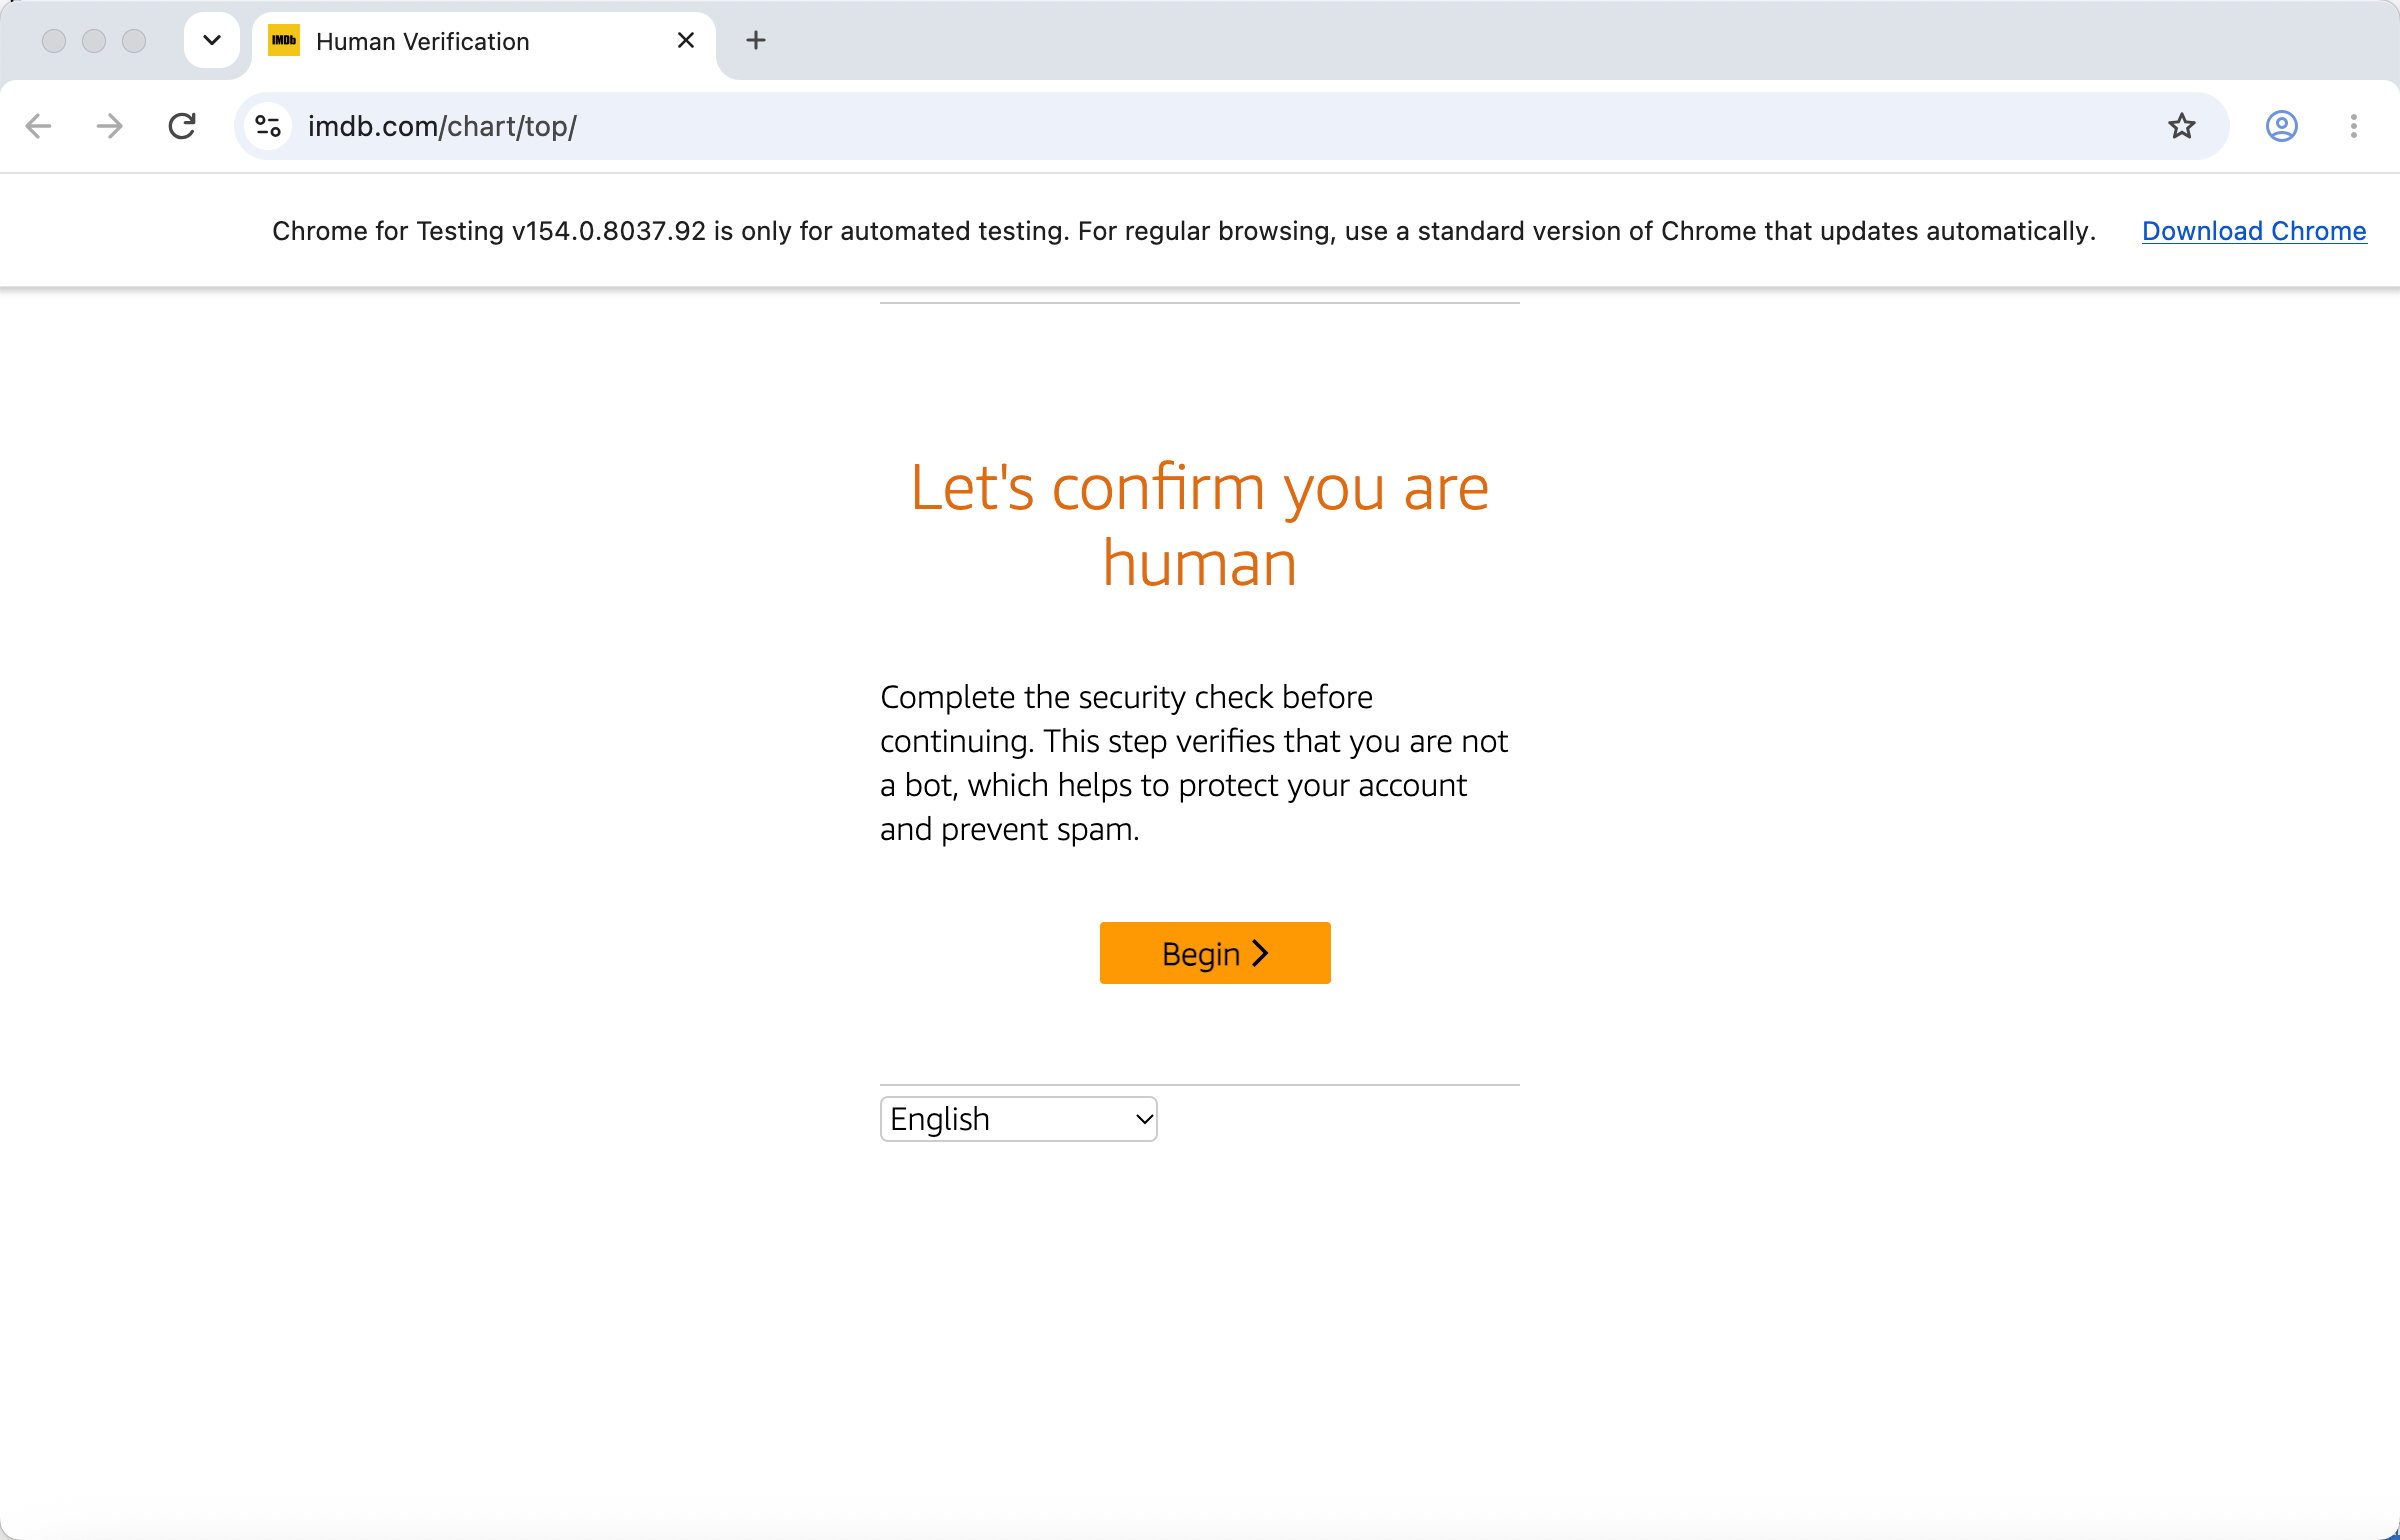

**Need to solve a CAPTCHA manually.**

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument("--lang=en-US")
driver = webdriver.Chrome(options=options)

try:
    driver.get("https://www.imdb.com/chart/top/")
    WebDriverWait(driver, 60).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "li.ipc-metadata-list-summary-item"))
    )
    html = driver.page_source
finally:
    driver.quit()

with open("imdb_page.html", "w", encoding="utf-8") as f:
    f.write(html)

soup = BeautifulSoup(html, "html.parser")
print("page title:", soup.title.get_text() if soup.title else None)
print("list items:", len(soup.select("li.ipc-metadata-list-summary-item")))
h3s = [h.get_text() for h in soup.find_all("h3", attrs={"class": "ipc-title__text"})]
print("h3 count:", len(h3s))
print(h3s[:10])

page title: IMDb Top 250 movies
list items: 250
h3 count: 3
['Chart insights', 'More to explore', 'Recently viewed']


In [ ]:
import json, re, html
import pandas as pd

data = json.loads(soup.find("script", type="application/ld+json").string)

def duration_to_minutes(d):
    m = re.match(r"PT(?:(\d+)H)?(?:(\d+)M)?", d or "")
    return int(m.group(1) or 0) * 60 + int(m.group(2) or 0) if m and d else None

rows = []
for rank, entry in enumerate(data["itemListElement"], start=1):
    movie = entry["item"]
    rating = movie.get("aggregateRating", {})
    rows.append({
        "rank": rank,
        "title": html.unescape(movie.get("name", "")),
        "rating": rating.get("ratingValue"),
        "votes": rating.get("ratingCount"),
        "genre": movie.get("genre"),
        "content_rating": movie.get("contentRating"),
        "duration_min": duration_to_minutes(movie.get("duration")),
        "url": movie.get("url"),
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(250, 8)


,rank,title,rating,votes,genre,content_rating,duration_min,url
0,1,The Shawshank Redemption,9.3,3247940,Drama,R,142,https://www.imdb.com/title/tt0111161/
1,2,The Godfather,9.2,2261969,"Crime, Drama",R,175,https://www.imdb.com/title/tt0068646/
2,3,The Dark Knight,9.1,3235275,"Crime, Thriller",PG-13,152,https://www.imdb.com/title/tt0468569/
3,4,The Godfather Part II,9.0,1517004,"Crime, Drama",R,202,https://www.imdb.com/title/tt0071562/
4,5,The Lord of the Rings: The Return of the King,9.0,2198303,"Adventure, Drama, Fantasy",PG-13,201,https://www.imdb.com/title/tt0167260/


In [ ]:
print(df.shape)
print(df.isna().sum())
df.to_csv("imdb_top250.csv", index=False, encoding="utf-8-sig")

(250, 8)
rank              0
title             0
rating            0
votes             0
genre             0
content_rating    6
duration_min      0
url               0
dtype: int64


In [ ]:
df[df["content_rating"].isna()][["rank", "title"]]

,rank,title
72,73,12th Fail
79,80,Kimi no na wa.
81,82,Das Boot
91,92,Shingeki no Kyojin: The Last Attack
222,223,Maharaja
246,247,Hababam Sinifi: Sinifta Kaldi


# Summary

- **IMDb blocks scrapers.** A normal User-Agent header didn't help: `requests` just got an empty page. I switched to Selenium to get into the page and still had to solve an image CAPTCHA manually.
- **Result:** 250 movies, 8 columns, saved as csv.
- **Data notes:** 6 movies have no content rating since they are non-US movies